# Imports

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt 
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


from matplotlib import pyplot as plt
from sklearn.manifold import TSNE

from sklearn.model_selection import train_test_split
from random import randint

import seaborn as sns

from boruta import BorutaPy
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

import shap

C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Preparation données

In [2]:
df = pd.read_csv('StudentsPerformance.csv')

#### Transformer les données catégorielle en données numériques

In [3]:
encoder = OneHotEncoder(sparse_output=False)
df['gender'] = encoder.fit_transform(df[['gender']])
df['race/ethnicity'] = encoder.fit_transform(df[['race/ethnicity']])
df['parental level of education'] = LabelEncoder().fit_transform(df[['parental level of education']])
df['lunch'] = encoder.fit_transform(df[['lunch']])
df['test preparation course'] = encoder.fit_transform(df[['test preparation course']])

C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


#### Normaliser les valeurs

In [4]:
scaler = StandardScaler()
columns = ['math score', 'reading score', 'children']

df['math score'] = scaler.fit_transform(df[['math score']])
df['reading score'] = scaler.fit_transform(df[['reading score']])

print(df)

     gender  race/ethnicity  parental level of education  lunch  \
0       1.0             0.0                            1    0.0   
1       1.0             0.0                            4    0.0   
2       1.0             0.0                            3    0.0   
3       0.0             1.0                            0    1.0   
4       0.0             0.0                            4    0.0   
..      ...             ...                          ...    ...   
995     1.0             0.0                            3    0.0   
996     0.0             0.0                            2    1.0   
997     1.0             0.0                            2    1.0   
998     1.0             0.0                            4    0.0   
999     1.0             0.0                            4    1.0   

     test preparation course  math score  reading score  writing score  
0                        0.0    0.390024       0.193999             74  
1                        1.0    0.192076       1.

In [5]:
y = df['writing score']
X = df.drop(columns=['writing score'])
X_columns = X.columns
print(X_columns)

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score'],
      dtype='object')


# 1. Analyse non-supervisée

## A. Clustering avec K-means

In [6]:
kmeans = KMeans(n_clusters=10)
kmeans.fit_predict(X)

array([6, 7, 0, 1, 0, 6, 0, 3, 2, 8, 1, 1, 2, 0, 8, 7, 4, 3, 8, 1, 2, 7,
       3, 7, 6, 2, 5, 6, 2, 2, 7, 9, 9, 3, 0, 4, 6, 9, 4, 1, 1, 6, 1, 5,
       1, 1, 6, 2, 6, 2, 5, 6, 3, 2, 7, 8, 4, 1, 5, 3, 6, 3, 1, 6, 9, 5,
       3, 9, 1, 1, 9, 5, 1, 5, 3, 1, 3, 4, 7, 2, 1, 8, 3, 6, 8, 7, 7, 6,
       9, 7, 6, 8, 2, 1, 0, 4, 5, 7, 9, 6, 5, 6, 4, 8, 0, 9, 0, 6, 6, 5,
       4, 8, 1, 9, 4, 2, 4, 4, 9, 9, 4, 4, 0, 8, 0, 4, 5, 7, 0, 1, 0, 3,
       0, 7, 6, 1, 3, 2, 6, 5, 7, 9, 9, 8, 0, 3, 0, 6, 6, 4, 5, 6, 6, 1,
       5, 7, 2, 5, 6, 6, 4, 7, 8, 8, 0, 4, 8, 2, 2, 7, 2, 0, 0, 6, 1, 0,
       8, 6, 9, 0, 2, 9, 8, 6, 3, 6, 2, 5, 3, 4, 6, 0, 9, 5, 2, 1, 5, 8,
       9, 4, 6, 7, 6, 6, 3, 5, 6, 2, 7, 9, 7, 3, 8, 1, 4, 0, 4, 8, 2, 5,
       2, 4, 9, 0, 1, 8, 7, 8, 5, 0, 5, 1, 6, 0, 4, 6, 6, 5, 5, 4, 2, 4,
       8, 5, 5, 4, 4, 2, 2, 2, 3, 7, 7, 0, 8, 7, 6, 6, 7, 2, 7, 0, 3, 4,
       2, 3, 6, 2, 4, 7, 6, 5, 1, 7, 0, 4, 0, 2, 7, 6, 8, 8, 6, 7, 3, 4,
       4, 7, 4, 7, 6, 0, 5, 6, 2, 6, 3, 6, 8, 4, 0,

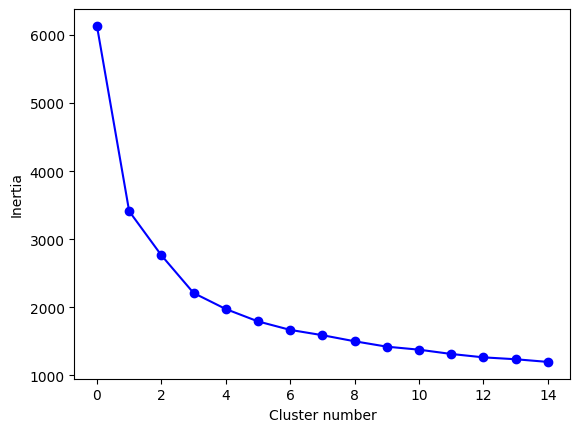

In [7]:
def get_inertia_plot(dataset, max_cluster):
    inertia_list = []

    for i in range(max_cluster):
        kmeans = KMeans(n_clusters=i+1)
        kmeans.fit_predict(dataset)
        inertia_list.append(kmeans.inertia_)

    plt.figure()
    plt.ylabel('Inertia')
    plt.xlabel('Cluster number')
    plt.plot(inertia_list, 'bo-')

    return inertia_list

inertias = get_inertia_plot(X, 15)

Une valeur optimale pour K peut être 9.

In [8]:
best_kmeans = KMeans(n_clusters=9)
best_kmeans.fit_predict(X)

array([6, 4, 1, 8, 4, 6, 4, 0, 5, 5, 8, 8, 1, 4, 5, 4, 1, 0, 0, 8, 5, 4,
       2, 4, 3, 1, 2, 6, 1, 5, 4, 2, 5, 0, 4, 7, 6, 2, 7, 8, 8, 6, 8, 2,
       8, 8, 6, 5, 6, 1, 2, 3, 2, 1, 4, 0, 7, 8, 2, 0, 3, 2, 8, 6, 2, 2,
       2, 2, 8, 8, 2, 2, 8, 2, 2, 8, 0, 3, 4, 5, 8, 5, 2, 3, 0, 4, 4, 6,
       2, 4, 6, 0, 1, 8, 4, 3, 2, 4, 2, 6, 4, 3, 7, 5, 4, 2, 1, 3, 6, 2,
       7, 5, 8, 2, 7, 1, 6, 7, 2, 2, 7, 7, 4, 5, 4, 1, 4, 4, 1, 8, 1, 2,
       4, 4, 3, 8, 2, 5, 6, 2, 4, 2, 2, 5, 4, 0, 4, 3, 6, 7, 2, 3, 6, 8,
       2, 4, 1, 2, 6, 3, 3, 4, 5, 5, 1, 7, 5, 5, 1, 4, 1, 4, 4, 6, 8, 1,
       5, 6, 5, 4, 5, 2, 5, 6, 2, 3, 1, 2, 2, 7, 6, 4, 2, 4, 1, 8, 2, 5,
       2, 6, 6, 4, 3, 6, 2, 4, 3, 1, 4, 2, 4, 0, 5, 8, 1, 4, 7, 0, 1, 2,
       5, 7, 2, 4, 6, 0, 4, 5, 2, 4, 4, 8, 6, 4, 7, 3, 3, 2, 2, 7, 1, 7,
       5, 2, 4, 3, 7, 5, 5, 5, 2, 4, 2, 1, 5, 4, 6, 3, 4, 1, 4, 4, 2, 1,
       1, 2, 6, 1, 7, 4, 3, 2, 8, 4, 4, 3, 4, 5, 4, 3, 5, 5, 6, 4, 2, 7,
       7, 4, 3, 4, 3, 4, 2, 6, 1, 3, 2, 3, 0, 7, 4,

## B. Réduction de dimensionnalité et visualisation

#### PCA

In [9]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

Text(0, 0.5, 'Deuxieme composante principale')

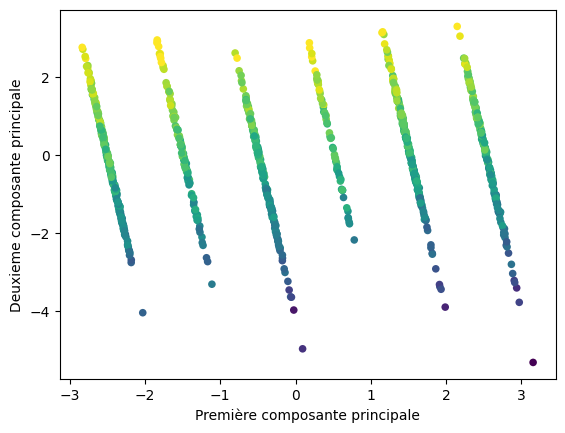

In [10]:
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, linewidths=0, s=30)
plt.xlabel("Première composante principale")
plt.ylabel("Deuxieme composante principale")

Visuellement les clusters n'ont pas l'air très bien séparés.

In [11]:
print(pca.explained_variance_ratio_)


[0.54874071 0.29901302]


La première composante explique 54.8% de la variance.
La deuxième composante explique 29.9% de la variance.

In [12]:
print(np.sum(pca.explained_variance_ratio_))
print(1-np.sum(pca.explained_variance_ratio_))

0.8477537321830348
0.15224626781696515


La réduction de dimensionnalité à 2 nous fait perdre énormément d'informations (15.22% de pertes) 

#### T-SNE

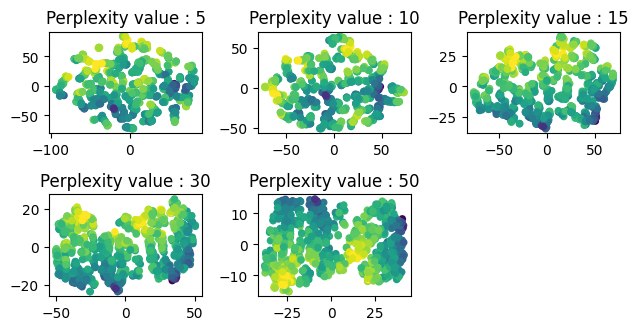

In [13]:
perplexity_values = [5,10,15,30,50]

for i, val in enumerate(perplexity_values):
    plt.subplot(3, 3, i + 1,)
    tsne = TSNE(n_components=2, perplexity=val)
    X_embedded = tsne.fit_transform(X)
    plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y, linewidths=0, s=30)
    plt.title(f"Perplexity value : {val}")
plt.tight_layout()
plt.show()

Visuellement, la séparation n'est ni intéressante avec la T-SNE ni avec la PCA.

# 2. Apprentissage supervisé

### A Préparation et sélection des features

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=randint(1,100))

<Axes: >

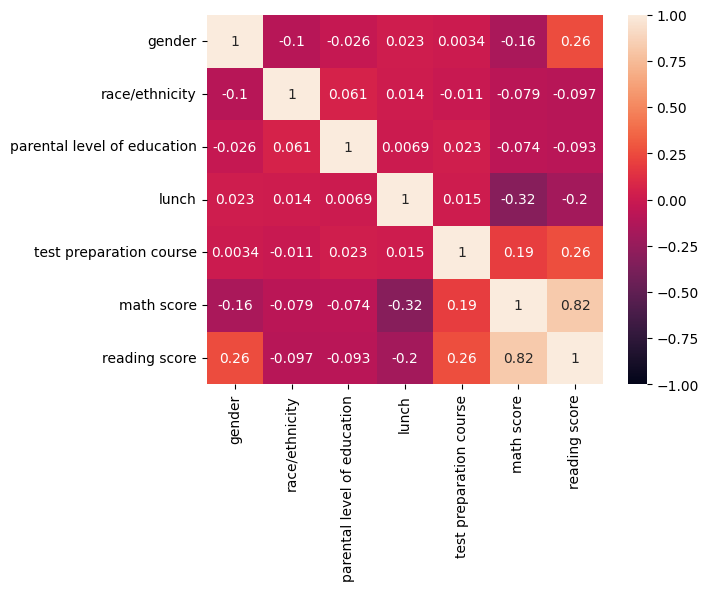

In [15]:
df_corr = pd.DataFrame(data=X_train, columns=X_columns)

matrix = df_corr.corr()

sns.heatmap(matrix, annot=True, vmin=-1, vmax=1)

On peut voir un couple de features fortement corrélées : reading score et math score (0.82)

In [16]:
def get_best_random_forest_regressor(X_train, y_train, X_test, y_test, param_grid_random_forest):
    result = {}
    result['RandomForest'] = {}
    random_forest = RandomForestRegressor()
    random_forest.fit(X_train, y_train)

    y_pred_train = random_forest.predict(X_train)
    y_pred_test = random_forest.predict(X_test)

    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    result['RandomForest']['default'] = {'train': mae_train, 'test': mae_test}

    randomized_search = RandomizedSearchCV(estimator=random_forest, scoring='neg_mean_absolute_error', param_distributions=param_grid_random_forest, cv=5, n_jobs=-1, n_iter=500)
    randomized_search.fit(X_train, y_train)

    random_forest_best_params = randomized_search.best_params_

    random_forest_best = randomized_search.best_estimator_
    y_pred_train = random_forest_best.predict(X_train)
    y_pred_test = random_forest_best.predict(X_test)

    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    result['RandomForest']['best'] = {'params':random_forest_best_params, 'train': mae_train, 'test': mae_test}

    return result

In [17]:
param_grid_random_forest = {
    'n_estimators': [20,100,200,300],
    'criterion': ['squared_error', 'absolute_error'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2,5,10,20],
    'min_samples_leaf': [1,2,4,6],
    'max_features': [None, 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

random_forest_result = get_best_random_forest_regressor(X_train, y_train, X_test, y_test, param_grid_random_forest)

In [18]:
random_forest_result['RandomForest']['best']['params']

{'n_estimators': 200,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 10,
 'criterion': 'squared_error',
 'bootstrap': True}

In [19]:
random_forest_best = RandomForestRegressor(n_estimators=300, min_samples_split=2 ,min_samples_leaf=2, max_features='sqrt', max_depth=40, criterion='squared_error', bootstrap=True)
random_forest_best.fit(X_train, y_train)

RandomForestRegressor(max_depth=40, max_features='sqrt', min_samples_leaf=2,
                      n_estimators=300)

In [20]:
feat_selector = BorutaPy(random_forest_best)

feat_selector.fit(X, y)

BorutaPy(estimator=RandomForestRegressor(max_depth=40, max_features='sqrt',
                                         min_samples_leaf=2, n_estimators=1000,
                                         random_state=RandomState(MT19937) at 0x20540166D40),
         random_state=RandomState(MT19937) at 0x20540166D40)

In [21]:
feat_selector.support_

array([ True, False, False, False,  True,  True,  True])

In [22]:
feat_selector_columns = feat_selector.support_
interesting_columns = []
for i in range(len(feat_selector_columns)):
    if feat_selector_columns[i] == True:
        interesting_columns.append(X_columns[i])

print(interesting_columns)

['gender', 'test preparation course', 'math score', 'reading score']


In [23]:
feat_selector.ranking_

array([1, 4, 3, 2, 1, 1, 1])

In [24]:
X = pd.DataFrame(data=X, columns=X_columns)
X = X.filter(interesting_columns)

print(X)


     gender  test preparation course  math score  reading score
0       1.0                      0.0    0.390024       0.193999
1       1.0                      1.0    0.192076       1.427476
2       1.0                      0.0    1.577711       1.770109
3       0.0                      0.0   -1.259543      -0.833899
4       0.0                      0.0    0.653954       0.605158
..      ...                      ...         ...            ...
995     1.0                      1.0    1.445746       2.044215
996     0.0                      0.0   -0.269803      -0.970952
997     1.0                      1.0   -0.467751       0.125472
998     1.0                      1.0    0.126093       0.605158
999     1.0                      0.0    0.719937       1.153370

[1000 rows x 4 columns]


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

### B. Entrainement et évaluation des modèles

In [26]:
def get_best_xgboost_regressor(X_train, y_train, X_test, y_test, param_grid_xgboost):
    result = {}
    result['XGBoost'] = {}
    xgboost = GradientBoostingRegressor()
    xgboost.fit(X_train, y_train)

    y_pred_train = xgboost.predict(X_train)
    y_pred_test = xgboost.predict(X_test)

    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    result['XGBoost']['default'] = {'train': mae_train, 'test': mae_test}

    randomized_search = RandomizedSearchCV(estimator=xgboost, scoring='neg_mean_absolute_error', param_distributions=param_grid_xgboost, cv=5, n_jobs=-1, n_iter=500)
    randomized_search.fit(X_train, y_train)

    xgboost_best_params = randomized_search.best_params_

    xgboost_best = randomized_search.best_estimator_
    y_pred_train = xgboost_best.predict(X_train)
    y_pred_test = xgboost_best.predict(X_test)

    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    result['XGBoost']['best'] = {'params':xgboost_best_params, 'train': mae_train, 'test': mae_test}

    return result

In [27]:
param_grid_xgboost = {
    "n_estimators" : [25, 50, 100, 200],
    "learning_rate" : [0.01, 0.1, 0.3],
    "max_depth" : [3, 4, 5, 6],
    "tol" : [0.0001, 0.001, 0.01, 1, 2, 3, 4, 5],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features" : [None, "sqrt", "log2"]
}

xgboost_result = get_best_xgboost_regressor(X_train, y_train, X_test, y_test, param_grid_xgboost)

In [28]:
xgboost_result

{'XGBoost': {'default': {'train': 2.6408348455648434,
   'test': 3.230063415415819},
  'best': {'params': {'tol': 5,
    'n_estimators': 100,
    'min_samples_split': 2,
    'min_samples_leaf': 2,
    'max_features': 'log2',
    'max_depth': 3,
    'learning_rate': 0.1},
   'train': 2.6771091916966916,
   'test': 3.2126086328675183}}}

In [29]:
mlp = MLPRegressor(hidden_layer_sizes=(64,32), activation='relu', max_iter=1000)
mlp.fit(X_train, y_train)

y_pred_train = mlp.predict(X_train)
y_pred_test = mlp.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(mae_test, mae_train)

3.0096594762863487 2.938235471956528


In [30]:
mlp = MLPRegressor(hidden_layer_sizes=(128,64,32), activation='relu', max_iter=1000)
mlp.fit(X_train, y_train)

y_pred_train = mlp.predict(X_train)
y_pred_test = mlp.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(mae_test, mae_train)

2.991486946357839 2.9231732782255


| Algo | Hyperparams | Train MAE | Test MAE |
|:----:|:-----------:|:-----:|:----:|
| XGBoost | default | 2.58 | 3.28 |
| XGBoost | {'tol': 2,'n_estimators': 100,'min_samples_split': 5,'min_samples_leaf': 1,'max_features': 'log2','max_depth': 3,'learning_rate': 0.1} | 2.64 | 3.14 |
| Neural Network | hidden_layer_sizes=(64,32), activation='relu', max_iter=1000 | 2.90 | 2.96 |
| Neural Network | hidden_layer_sizes=(128,64,32), activation='relu', max_iter=1000 | 2.98 | 2.91 |


Je pense que le meilleur modèle est le Neural Network avec les hyperparametres suivants : hidden_layer_sizes=(64,32), activation='relu', max_iter=1000

# 3. Combinaison et explicabilité

### A. Ingénierie des features via clustering

In [31]:
cluster_labels = best_kmeans.fit_predict(X)
df['Cluster_KMeans'] = cluster_labels

In [32]:
display(df.head())

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Cluster_KMeans
0,1.0,0.0,1,0.0,0.0,0.390024,0.193999,74,0
1,1.0,0.0,4,0.0,1.0,0.192076,1.427476,88,8
2,1.0,0.0,3,0.0,0.0,1.577711,1.770109,93,7
3,0.0,1.0,0,1.0,0.0,-1.259543,-0.833899,44,2
4,0.0,0.0,4,0.0,0.0,0.653954,0.605158,75,6


In [33]:
y = df['writing score']
X = df.drop(columns=['writing score'])
X_columns = X.columns
print(X_columns)

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'Cluster_KMeans'],
      dtype='object')


In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=randint(1,100))

In [35]:
param_grid_xgboost = {
    "n_estimators" : [25, 50, 100, 200],
    "learning_rate" : [0.01, 0.1, 0.3],
    "max_depth" : [3, 4, 5, 6],
    "tol" : [0.0001, 0.001, 0.01, 1, 2, 3, 4, 5],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features" : [None, "sqrt", "log2"]
}

xgboost_result = get_best_xgboost_regressor(X_train, y_train, X_test, y_test, param_grid_xgboost)

In [36]:
xgboost_result

{'XGBoost': {'default': {'train': 2.441390213298743,
   'test': 3.1339681190260316},
  'best': {'params': {'tol': 0.01,
    'n_estimators': 50,
    'min_samples_split': 2,
    'min_samples_leaf': 4,
    'max_features': None,
    'max_depth': 4,
    'learning_rate': 0.1},
   'train': 2.3852603175596756,
   'test': 3.1437292416232054}}}

In [37]:
mlp = MLPRegressor(hidden_layer_sizes=(64,32), activation='relu', max_iter=1000)
mlp.fit(X_train, y_train)

y_pred_train = mlp.predict(X_train)
y_pred_test = mlp.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(mae_test, mae_train)

3.258955326603789 2.849390067899396


In [38]:
mlp = MLPRegressor(hidden_layer_sizes=(128,64,32), activation='relu', max_iter=1000)
mlp.fit(X_train, y_train)

y_pred_train = mlp.predict(X_train)
y_pred_test = mlp.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(mae_test, mae_train)

3.267126461824608 2.667129494379123


| Algo | Hyperparams | Train MAE | Test MAE |
|:----:|:-----------:|:-----:|:----:|
| XGBoost | default | 2.51 | 3.00 |
| XGBoost | {'tol': 0.0001,'n_estimators': 200,'min_samples_split': 2,'min_samples_leaf': 1,'max_features': 'log2','max_depth': 3,'learning_rate': 0.1} | 2.31 | 2.97 |
| Neural Network | hidden_layer_sizes=(64,32), activation='relu', max_iter=1000 | 3.06 | 2.89 |
| Neural Network | hidden_layer_sizes=(128,64,32), activation='relu', max_iter=1000 | 3.07 | 2.74 |


Je pense que le meilleur modèle est le Neural Network avec les hyperparametres suivants : hidden_layer_sizes=(64,32), activation='relu', max_iter=1000

### B. Explicabilité du modèle supervisé

In [39]:
random_forest_best.fit(X_test, y_test)

RandomForestRegressor(max_depth=40, max_features='sqrt', min_samples_leaf=2,
                      n_estimators=1000,
                      random_state=RandomState(MT19937) at 0x20540166D40)

In [40]:
explainer = shap.Explainer(random_forest_best)
shap_values = explainer.shap_values(X_test)

#### Summary plot en bar

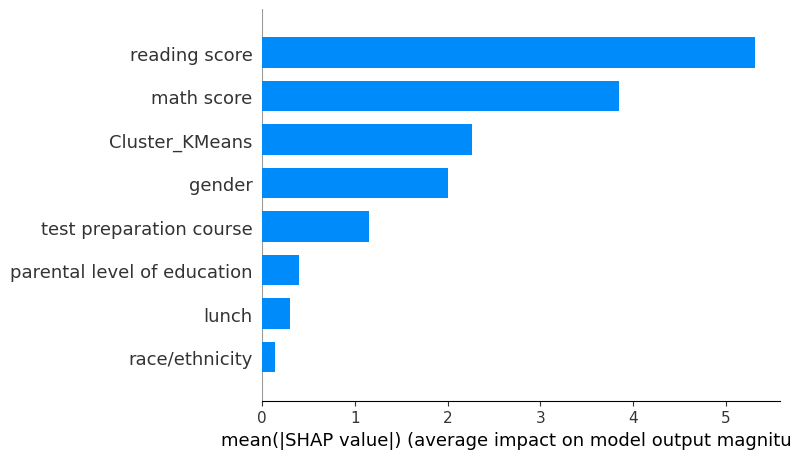

In [41]:
shap.summary_plot(shap_values, X_test, feature_names=X.columns, plot_type='bar')

On remarque que les 3 features qui ont le plus d'importances sont : reading score, math score et gender 

Les 3 features qui ont le moins d'importances sont : race/ethnicity, parental level of education et lunch

#### Summary plot classique

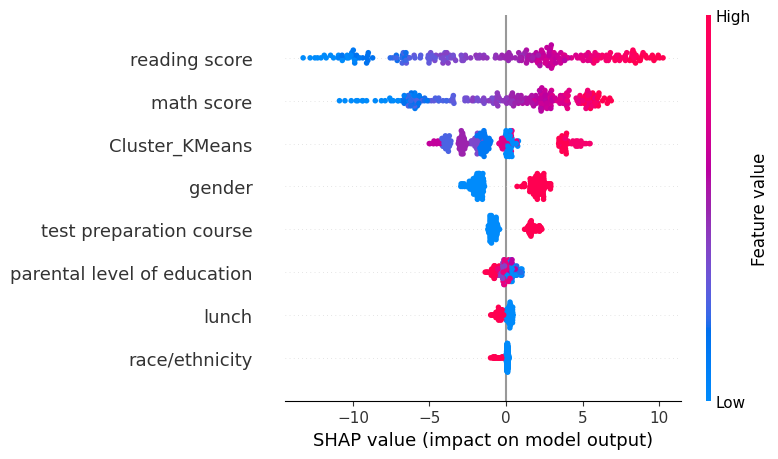

In [42]:
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

Ici on remarque que plus le reading score et le math score sont élevé plus cela va avoir un impact positif sur le modèle (avoir un bon writing score).

On remarque aussi que selon la valeur de la feature gender, cela va impacter le résultat du modèle de manière positif pour l'un et négatif pour l'autre. 

#### Waterfall plot

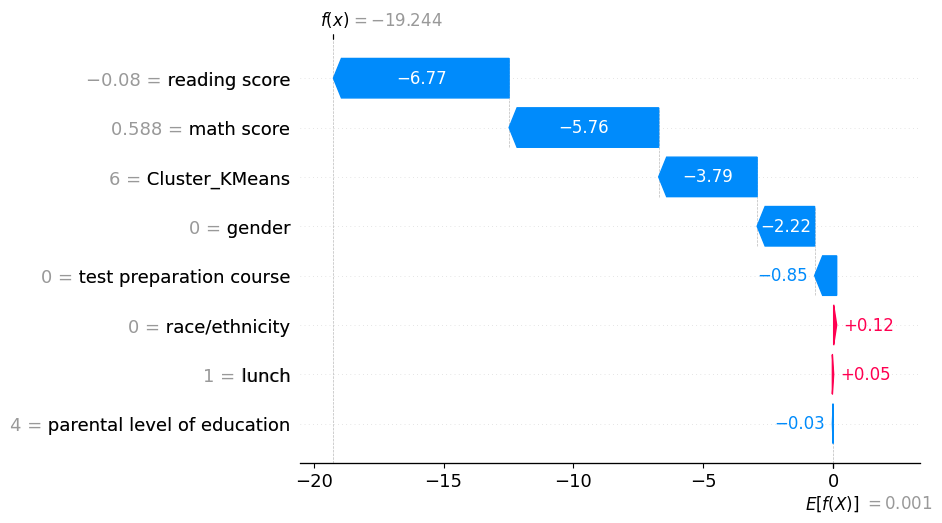

In [43]:
instance_idx=20
shap.waterfall_plot(shap.Explanation(values=shap_values[instance_idx],
                                    base_values=shap_values.mean(),
                                    data=X_train.iloc[instance_idx],
                                    feature_names=X_train.columns)              
                    )


On peut voir ici que les features maths core et reading score on eu un grand impact positif sur le résultat du modèle et que la feature gender a eu un impact négatif.

#### Ice plots

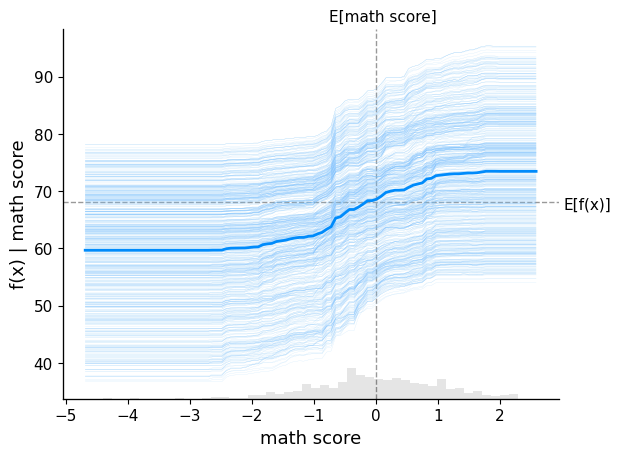

In [44]:
shap.plots.partial_dependence(
        ind = X_train.columns.get_loc('math score'),
        feature_names= X_columns,
        model=random_forest_best.predict,
        data=X_train,
        model_expected_value=True,
        feature_expected_value=True,
        ice=True,
    )

On remarque que plus la feature math score augmente plus la valeur de la prédiction augmente.

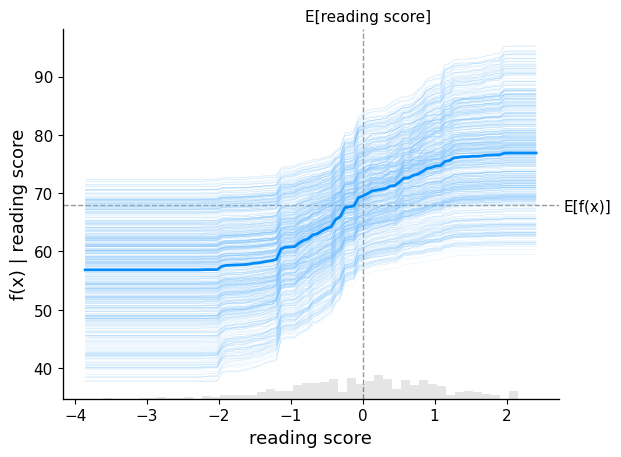

In [45]:
shap.plots.partial_dependence(
        ind = X_train.columns.get_loc('reading score'),
        feature_names= X_columns,
        model=random_forest_best.predict,
        data=X_train,
        model_expected_value=True,
        feature_expected_value=True,
        ice=True,
    )

On remarque que plus la feature reading score augmente plus la valeur de la prédiction augmente.

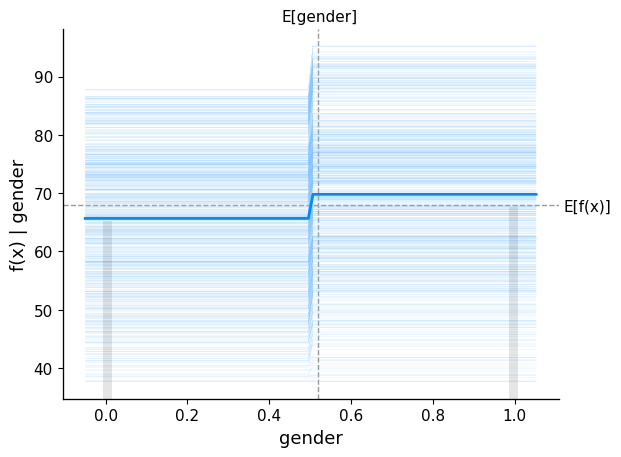

In [46]:
shap.plots.partial_dependence(
        ind = X_train.columns.get_loc('gender'),
        feature_names= X_columns,
        model=random_forest_best.predict,
        data=X_train,
        model_expected_value=True,
        feature_expected_value=True,
        ice=True,
    )

On remarque que la feature gender impact légérement le résultat du modèle.

### C. Conclusion

Pour ce jeu de données, l'ajout d'une feature correspondant aux clusters n'a pas eu d'impact.

Cela s'explique avec les résultats obtenus lors de la PCA et du T-SNE où nousa vons pu voir qu'il était compliqué de créer des clusters précis.